In [5]:
import sys
sys.path.append("../src")
from data_processing import (
    clean_indicators,
    create_age_group,
    select_indicators
)
import pandas as pd
import os

print(os.getcwd())
print(os.listdir())

df = pd.read_csv(
    "../data/health_data_11_09_2026 (1).csv"
)

df.head()

#clean indicators
df = clean_indicators(df)

#cleaning the missing variables in the Age Group column
df = df.dropna(subset=["Age Group"])

#creating new Age Groups
df = create_age_group(df)

#defining the indicators
indicators = [
    "Percentage distribution of women who have been tested for the AIDS virus",
    "Percentage of men who think that discussion of AIDS in the media is not acceptable in any media",
    "Percentage of men with a comprehensive knowledge about AIDS",
    "Percentage of individuals who have heard of AIDS",
    "Percentage of individuals who have received information about AIDS from specific sources",
    "Percentage of men who know a source for the HIV test"
]

#run
result = select_indicators(df, indicators)

result


c:\Users\Lenovo\Documents\MSDS\SEM 1\OBJECT ORIENTED PROGRAMMING\HIV Awareness\notebooks
['hiv_awareness.ipynb']


,Indicator,Age.Group.New,Value,Gender
7,Percentage distribution of women who have been...,15 - 29 Years,11,Female
8,Percentage distribution of women who have been...,35 - 49 Years,7,Female
9,Percentage distribution of women who have been...,35 - 49 Years,5,Female
15,Percentage distribution of women who have been...,15 - 29 Years,11,Female
16,Percentage of individuals who have received in...,15 - 29 Years,5,Male
17,Percentage of individuals who have received in...,15 - 29 Years,3,Male
26,Percentage of men with a comprehensive knowled...,35 - 49 Years,45,Male
28,Percentage of individuals who have heard of AIDS,15 - 29 Years,6,Male
29,Percentage of individuals who have heard of AIDS,15 - 29 Years,12,Male
30,Percentage of individuals who have heard of AIDS,15 - 29 Years,25,Male


Original columns:
['Indicator', 'Period', 'Age Group', 'Gender', 'Location', 'Value']

Number of rows: 95
['Indicator', 'Period', 'Age Group', 'Gender', 'Location', 'Value']
Columns after creating age groups:
['Indicator', 'Period', 'Age Group', 'Gender', 'Location', 'Value', 'Age.Group.New']


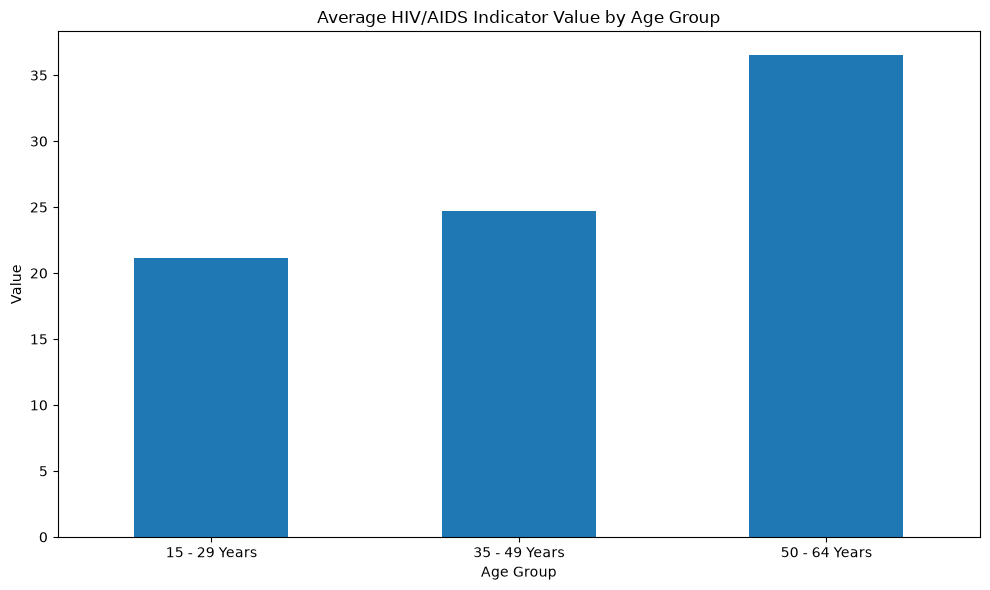

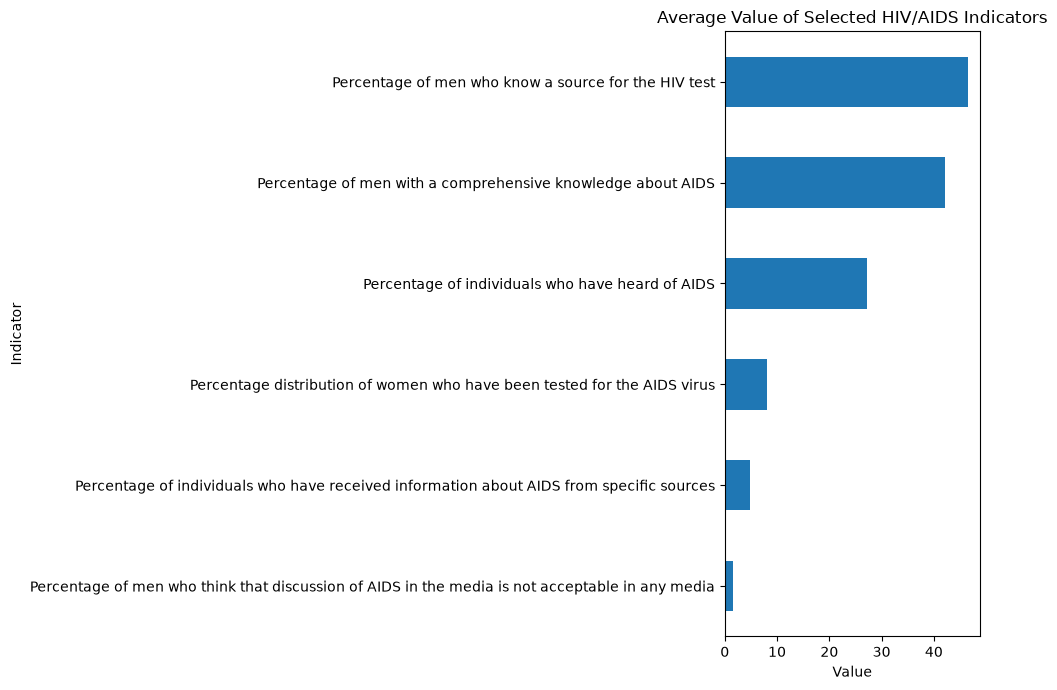

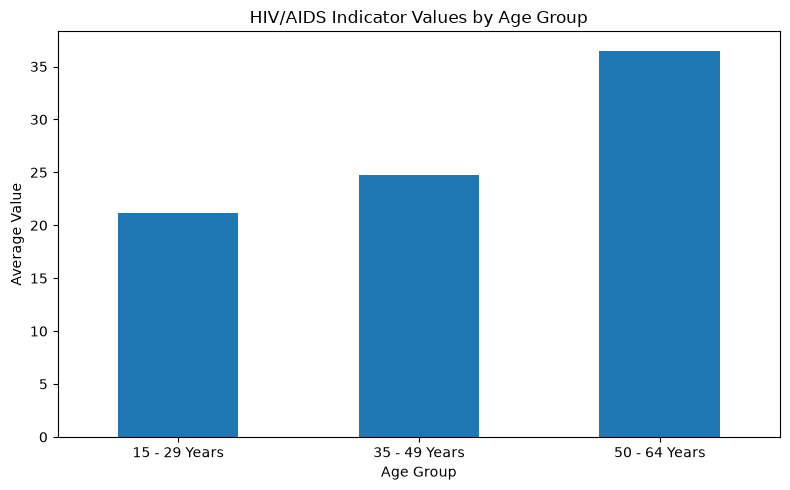

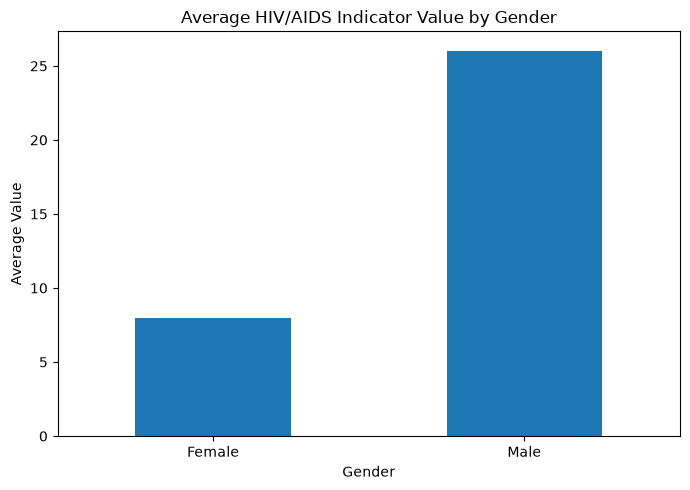

In [ ]:
#Data visualization.
import sys
from pathlib import Path

# Find the src folder
src_path = Path("../src").resolve()

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

import pandas as pd
import matplotlib.pyplot as plt

from data_processing import (
    clean_indicators,
    create_age_group,
    select_indicators
)

df = pd.read_csv(
    "../data/health_data_11_09_2026 (1).csv"
)

print("Original columns:")
print(df.columns.tolist())

print("\nNumber of rows:", len(df))

# Remove rows where Age Group is missing
df = df.dropna(subset=["Age Group"])

# Clean indicator names
df = clean_indicators(df)

print(df.columns.tolist())

df = create_age_group(df)

print("Columns after creating age groups:")
print(df.columns.tolist())

#Create your six-indicator result
indicators = [
    "Percentage distribution of women who have been tested for the AIDS virus",
    "Percentage of men who think that discussion of AIDS in the media is not acceptable in any media",
    "Percentage of men with a comprehensive knowledge about AIDS",
    "Percentage of individuals who have heard of AIDS",
    "Percentage of individuals who have received information about AIDS from specific sources",
    "Percentage of men who know a source for the HIV test"
]

result = select_indicators(df, indicators)

result

#Visualization — Values by age group
plt.figure(figsize=(10, 6))

result.groupby("Age.Group.New")["Value"].mean().plot(
    kind="bar"
)

plt.title("Average HIV/AIDS Indicator Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Visualization  — The six indicators
indicator_values = (
    result.groupby("Indicator")["Value"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 7))

indicator_values.plot(kind="barh")

plt.title("Average Value of Selected HIV/AIDS Indicators")
plt.xlabel("Value")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

#Visualization — Compare age groups
age_values = (
    result.groupby("Age.Group.New")["Value"]
    .mean()
)

plt.figure(figsize=(8, 5))

age_values.plot(
    kind="bar"
)

plt.title("HIV/AIDS Indicator Values by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Visualization — Gender comparison
gender_values = (
    result.groupby("Gender")["Value"]
    .mean()
)

plt.figure(figsize=(7, 5))

gender_values.plot(kind="bar")

plt.title("Average HIV/AIDS Indicator Value by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# Comprehensive knowledge among men

indicators = [
    "Percentage distribution of women who have been tested for the AIDS virus",
    "Percentage of men who think that discussion of AIDS in the media is not acceptable in any media",
    "Percentage of men with a comprehensive knowledge about AIDS",
    "Percentage of individuals who have heard of AIDS",
    "Percentage of individuals who have received information about AIDS from specific sources",
    "Percentage of men who know a source for the HIV test"
]

# Keep only the selected indicators
ml_data = df[df["Indicator"].isin(indicators)].copy()

# Check whether the indicators were found
print("Number of rows:", len(ml_data))
print("\nIndicators found:")
print(ml_data["Indicator"].unique())

# Convert the long-format data into wide format

ml_wide = ml_data.pivot_table(
    index=["Period", "Age Group", "Location"],
    columns="Indicator",
    values="Value",
    aggfunc="mean"
).reset_index()

print(ml_wide.head())
print("\nColumns:")
print(ml_wide.columns.tolist())

ml_wide = ml_wide.rename(columns={
    "Percentage distribution of women who have been tested for the AIDS virus":
        "HIV Testing",

    "Percentage of men who think that discussion of AIDS in the media is not acceptable in any media":
        "AIDS Discussion Not Acceptable",

    "Percentage of men with a comprehensive knowledge about AIDS":
        "Comprehensive Knowledge",

    "Percentage of individuals who have heard of AIDS":
        "Heard of AIDS",

    "Percentage of individuals who have received information about AIDS from specific sources":
        "AIDS Information",

    "Percentage of men who know a source for the HIV test":
        "Know HIV Test Source"
})

print(ml_wide.columns.tolist())

# Remove rows where the target is missing
ml_wide = ml_wide.dropna(
    subset=["Comprehensive Knowledge"]
)

# Predictor variables
X = ml_wide[
    [
        "HIV Testing",
        "AIDS Discussion Not Acceptable",
        "Heard of AIDS",
        "AIDS Information",
        "Know HIV Test Source"
    ]
]

# Target variable
y = ml_wide["Comprehensive Knowledge"]

print("X shape:", X.shape)
print("y shape:", y.shape)


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Number of rows: 35

Indicators found:
<StringArray>
[                       'Percentage distribution of women who have been tested for the AIDS virus',
        'Percentage of individuals who have received information about AIDS from specific sources',
                                     'Percentage of men with a comprehensive knowledge about AIDS',
                                                'Percentage of individuals who have heard of AIDS',
                                            'Percentage of men who know a source for the HIV test',
 'Percentage of men who think that discussion of AIDS in the media is not acceptable in any media']
Length: 6, dtype: str
Indicator  Period      Age Group Location  \
0            2001  15 - 19 Years   Uganda   
1            2001  20 - 24 Years   Uganda   
2            2001  25 - 29 Years   Uganda   
3            2001  30 - 34 Years   Uganda   
4            2001  30 - 39 Years   Uganda   

Indicator  Percentage distribution of women who have be